In [1]:
import os
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

# import warnings
# warnings.filterwarnings('ignore')

%matplotlib inline

# use daily averages

In [2]:
# Define SARIMA model
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [ ]:
# Forecasting 
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season = []
            
        for i in range(train_len, total_len, window):
            last_season = df[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [ ]:
path = "../../datasets/TxSON_data_2026-02-24/"
stations_list = ['CB01', 'CB04', 'CB06', 'CB07', 'CB09', 'CB10']

dfs = {}
for code in stations_list:
    filename = path + code + '.dat'
    print(filename)
    df = pd.read_csv(filename, skiprows=5, parse_dates=['Date'], index_col='Date')
    dfs[code] = df

dfs['CB01']

In [ ]:
# Drop Flag; drop SWC_50 and T_50 (CB07 lacks them, errors='ignore' handles that)
for key in dfs.keys():
    dfs[key].drop(['Flag'], axis=1, inplace=True)
    dfs[key].drop(['SWC_50', 'T_50'], axis=1, errors='ignore', inplace=True)

In [15]:
#drop flag feature and null values

# for station, df in dfs.items() :
#   # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
#   df = df.drop('Flag', axis = 1)
#   # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
#   df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
#   df_new.dropna(inplace=True)
#   dfs[station] = df_new

In [ ]:
# TxSON soil files do not contain wind data — wind vectorization skipped

In [17]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

In [19]:
# # create one standard metric for PPT
# for key in dfs.keys():
#   dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [20]:
#Normalize all the data

for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [ ]:
# Geographic coordinates are not included in TxSON .dat files — position features skipped

In [22]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


55028


# Create Multi-Index DF for all Station Data

In [ ]:
feats = dfs['CB01'].columns.tolist()

stations = list(dfs.keys())

In [24]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [25]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [26]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 SWC_50,Station1 T_5,Station1 T_10,Station1 T_20,Station1 T_50,Station1 Tair,Station1 RH,...,Station6 Srad,Station6 Ppt,Station6 Latitude,Station6 Longitude,Station6 Wx,Station6 Wy,Station6 Day sin,Station6 Day cos,Station6 Year sin,Station6 Year cos
2015-01-01 00:00:00,0.362264,0.439252,0.416107,0.401235,0.041667,0.061416,0.078304,0.156590,0.809929,0.905756,...,0.000000,0.0,30.2758,-98.7242,0.649683,0.674570,0.500000,1.000000,0.500753,0.999999
2015-01-01 01:00:00,0.362264,0.439252,0.416107,0.401235,0.042683,0.060947,0.076743,0.154552,0.810174,0.906775,...,0.000505,0.0,30.2758,-98.7242,0.645757,0.662373,0.629410,0.982963,0.501111,0.999999
2015-01-01 02:00:00,0.362264,0.439252,0.416107,0.401235,0.043293,0.060244,0.075442,0.153193,0.810442,0.908304,...,0.000000,0.0,30.2758,-98.7242,0.645532,0.684388,0.750000,0.933013,0.501469,0.999998
2015-01-01 03:00:00,0.362264,0.439252,0.416107,0.401235,0.043496,0.059775,0.074402,0.151155,0.811228,0.907794,...,0.000000,0.0,30.2758,-98.7242,0.635315,0.683527,0.853553,0.853553,0.501828,0.999997
2015-01-01 04:00:00,0.362264,0.439252,0.416107,0.401235,0.044715,0.059541,0.073621,0.149457,0.811271,0.949058,...,0.000000,0.0,30.2758,-98.7242,0.635953,0.629647,0.933013,0.750000,0.502186,0.999995


In [27]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

In [28]:
df.tail()

Station              Station1                                          \
Feature                 SWC_5    SWC_10    SWC_20    SWC_50       T_5   
2021-06-06 09:00:00  0.758491  0.551402  0.718121  0.734568  0.455285   
2021-06-06 10:00:00  0.758491  0.546729  0.711409  0.728395  0.468496   
2021-06-06 11:00:00  0.758491  0.546729  0.711409  0.728395  0.498984   
2021-06-06 12:00:00  0.754717  0.546729  0.711409  0.728395  0.554472   
2021-06-06 13:00:00  0.747170  0.546729  0.711409  0.728395  0.601829   

Station                                                                ...  \
Feature                  T_10      T_20      T_50      Tair        RH  ...   
2021-06-06 09:00:00  0.498594  0.533559  0.604620  0.920141  0.941416  ...   
2021-06-06 10:00:00  0.505860  0.534860  0.603261  0.924188  0.906775  ...   
2021-06-06 11:00:00  0.518987  0.539282  0.601902  0.935012  0.863627  ...   
2021-06-06 12:00:00  0.550398  0.549688  0.600883  0.942259  0.838767  ...   
2021-06-06 13:00:00  0.588608  0.569199  0.599524  0.946776  0.833316  ...   

Station              Station6                                              \
Feature                  Srad  Ppt Latitude Longitude        Wx        Wy   
2021-06-06 09:00:00  0.152973  0.0  30.2758  -98.7242  0.409350  0.608478   
2021-06-06 10:00:00  0.430991  0.0  30.2758  -98.7242  0.449031  0.668760   
2021-06-06 11:00:00  0.777477  0.0  30.2758  -98.7242  0.375301  0.659724   
2021-06-06 12:00:00  0.873874  0.0  30.2758  -98.7242  0.372571  0.608229   
2021-06-06 13:00:00  0.881982  0.0  30.2758  -98.7242  0.353124  0.652895   

Station                                                      
Feature               Day sin   Day cos  Year sin  Year cos  
2021-06-06 09:00:00  0.853553  0.146447  0.713254  0.047758  
2021-06-06 10:00:00  0.750000  0.066987  0.712929  0.047605  
2021-06-06 11:00:00  0.629410  0.017037  0.712605  0.047453  
2021-06-06 12:00:00  0.500000  0.000000  0.712281  0.047300  
2021-06-06 13:00:00  0.370590  0.017037  0.711956  0.047148  

[5 rows x 120 columns]

In [29]:
df.index = pd.to_datetime(df.index)
df = df.resample('M').mean()

# Data Split

In [ ]:
num_predictions = 10
total_len = len(df.CB01.SWC_5)
train_len = total_len - num_predictions
test_len = num_predictions

In [ ]:
df_train_station1 = df.CB01.SWC_5[:train_len]
df_test_station1 = df.CB01.SWC_5[train_len:]
df_total_station1 = df.CB01.SWC_5

In [32]:
# Define range of parameter's to check
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = range(0, 3, 1)
Qs = range(0, 3, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [33]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train_station1, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/81 [00:00<?, ?it/s]

[(0, 0, 0, 0), 67.59587116340121]
[(0, 0, 0, 1), 18.179940896813193]
[(0, 0, 0, 2), -5.368361388930312]
[(0, 0, 1, 0), -47.45236406785862]
[(0, 0, 1, 1), -53.151054839108724]
[(0, 0, 1, 2), -52.44385807450729]
[(0, 0, 2, 0), -54.082252778531036]
[(0, 0, 2, 1), -52.51948858768838]
[(0, 0, 2, 2), -51.12304556736593]
[(0, 1, 0, 0), 10.335849848235526]
[(0, 1, 0, 1), -18.121616927575843]
[(0, 1, 0, 2), -31.171246886780565]
[(0, 1, 1, 0), -56.23592335525219]
[(0, 1, 1, 1), -63.670856081155094]
[(0, 1, 1, 2), -62.64068580696369]
[(0, 1, 2, 0), -61.608591647699456]
[(0, 1, 2, 1), -62.6894982531024]
[(0, 1, 2, 2), -60.20157896353717]
[(0, 2, 0, 0), -29.430251026856943]
[(0, 2, 0, 1), -48.337365097721914]
[(0, 2, 0, 2), -55.28853043444211]
[(0, 2, 1, 0), -66.9462726525809]
[(0, 2, 1, 1), -71.13344215098168]
[(0, 2, 1, 2), -70.82830455432834]
[(0, 2, 2, 0), -69.96882373543295]
[(0, 2, 2, 1), -70.85401719537296]
[(0, 2, 2, 2), -68.32153187655905]
[(1, 0, 0, 0), -79.39115018504337]
[(1, 0, 0, 1), 

,"(p,q,P,Q)",AIC
0,"(2, 1, 0, 1)",-88.659592
1,"(2, 1, 1, 0)",-88.282303
2,"(2, 1, 2, 0)",-88.022825
3,"(2, 1, 1, 1)",-88.001169
4,"(2, 1, 0, 2)",-87.637315
...,...,...
76,"(0, 1, 0, 1)",-18.121617
77,"(0, 0, 0, 2)",-5.368361
78,"(0, 1, 0, 0)",10.335850
79,"(0, 0, 0, 1)",18.179941


In [44]:
SARIMA_result_df

,"(p,q,P,Q)",AIC
0,"(2, 1, 0, 1)",-88.659592
1,"(2, 1, 1, 0)",-88.282303
2,"(2, 1, 2, 0)",-88.022825
3,"(2, 1, 1, 1)",-88.001169
4,"(2, 1, 0, 2)",-87.637315
...,...,...
76,"(0, 1, 0, 1)",-18.121617
77,"(0, 0, 0, 2)",-5.368361
78,"(0, 1, 0, 0)",10.335850
79,"(0, 0, 0, 1)",18.179941


In [45]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train_station1, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              SWC_5   No. Observations:                   68
Model:             SARIMAX(2, 0, 1)x(0, 0, 1, 12)   Log Likelihood                  40.248
Date:                            Sat, 14 Oct 2023   AIC                            -70.497
Time:                                    15:41:32   BIC                            -60.552
Sample:                                01-31-2015   HQIC                           -66.661
                                     - 08-31-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4374      0.171      8.388      0.000       1.102       1.773
ar.L2         -0.4377      0.170   

In [46]:
pred_df = df_test_station1.copy()

In [47]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len/5)

In [48]:
pred_df['SARIMA'] = rolling_forecast(df_total_station1, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

In [49]:
pred_df['last_season'] = rolling_forecast(df_train_station1, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

In [50]:
pred_df

2020-09-30 00:00:00                                             0.539213
2020-10-31 00:00:00                                             0.222048
2020-11-30 00:00:00                                             0.228239
2020-12-31 00:00:00                                             0.379884
2021-01-31 00:00:00                                             0.612979
2021-02-28 00:00:00                                             0.589847
2021-03-31 00:00:00                                             0.418117
2021-04-30 00:00:00                                             0.299581
2021-05-31 00:00:00                                             0.581076
2021-06-30 00:00:00                                             0.766601
SARIMA                 [0.23119256312124356, 0.31945759513846916, 0.3...
last_season                   [0.17631872590789208, 0.15623858794887402]
Name: SWC_5, dtype: object

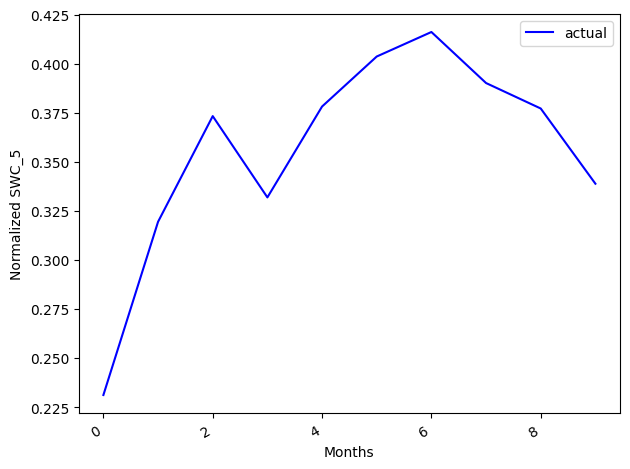

In [51]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total_station1)
ax.plot(pred_df.SARIMA, 'b-', label='actual')
# ax.plot(pred_df[:10], 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

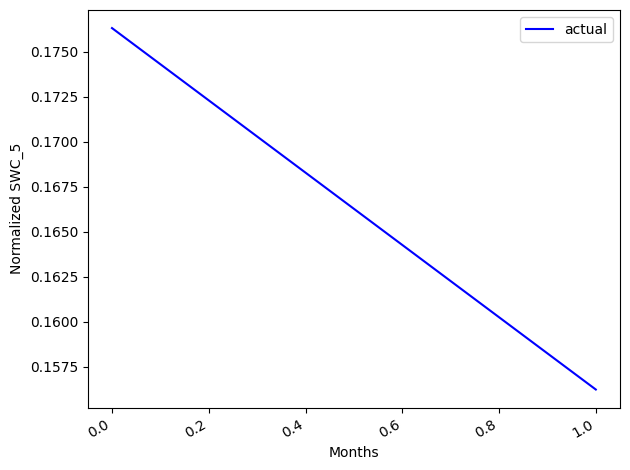

In [52]:
# visualize predictions
fig, ax = plt.subplots()

# ax.plot(df_total_station1)
ax.plot(pred_df.last_season, 'b-', label='actual')
# ax.plot(pred_df[:10], 'k--', label='SARIMA')
ax.set_xlabel('Months')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [53]:
# Evaluate 
mse=np.mean((pred_df[:10]-pred_df.SARIMA)**2)
mse

0.04502511018967628